# Image Classification on CIFAR-10 Dataset Using CNN

<img src="https://cs217.stanford.edu/assets/img/cifar.jpg" width="800"/>

##### We will work on an image dataset called CIFAR-10, build an image classification model using a Convolutional Neural Network (CNN), train the model with the data, and then test and evaluate the performance of the trained model.

### Import Libraries

In [1]:
#pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Import Dataset

CIFAR-10 Dataset Information:

- 10 classes (e.g., airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)

- 60,000 images in total

- 50,000 for training

- 10,000 for testing

- Image size: 32x32 pixels, RGB (3 channels)

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


### EDA

In [4]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

(_, y_train_labels), (_, y_test_labels) = cifar10.load_data()

unique, counts = np.unique(y_train_labels, return_counts=True)

for i in range(len(class_names)):
    print(f"{class_names[i]}: {counts[i]} image")

airplane: 5000 image
automobile: 5000 image
bird: 5000 image
cat: 5000 image
deer: 5000 image
dog: 5000 image
frog: 5000 image
horse: 5000 image
ship: 5000 image
truck: 5000 image


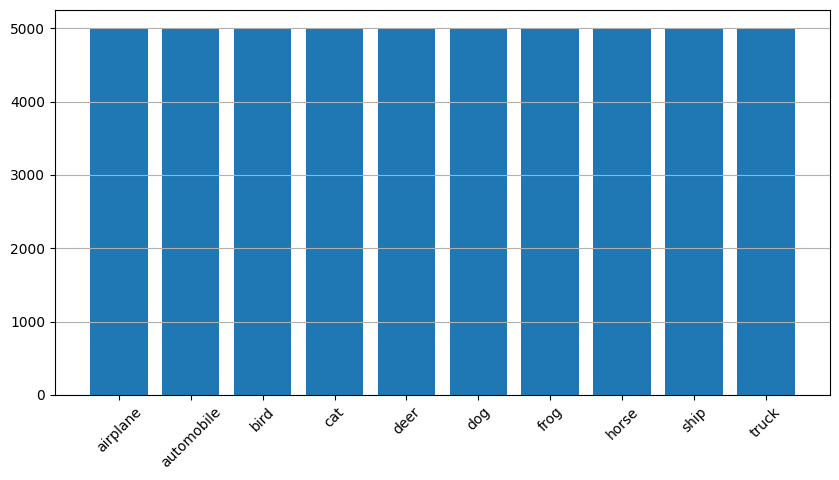

In [6]:
plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

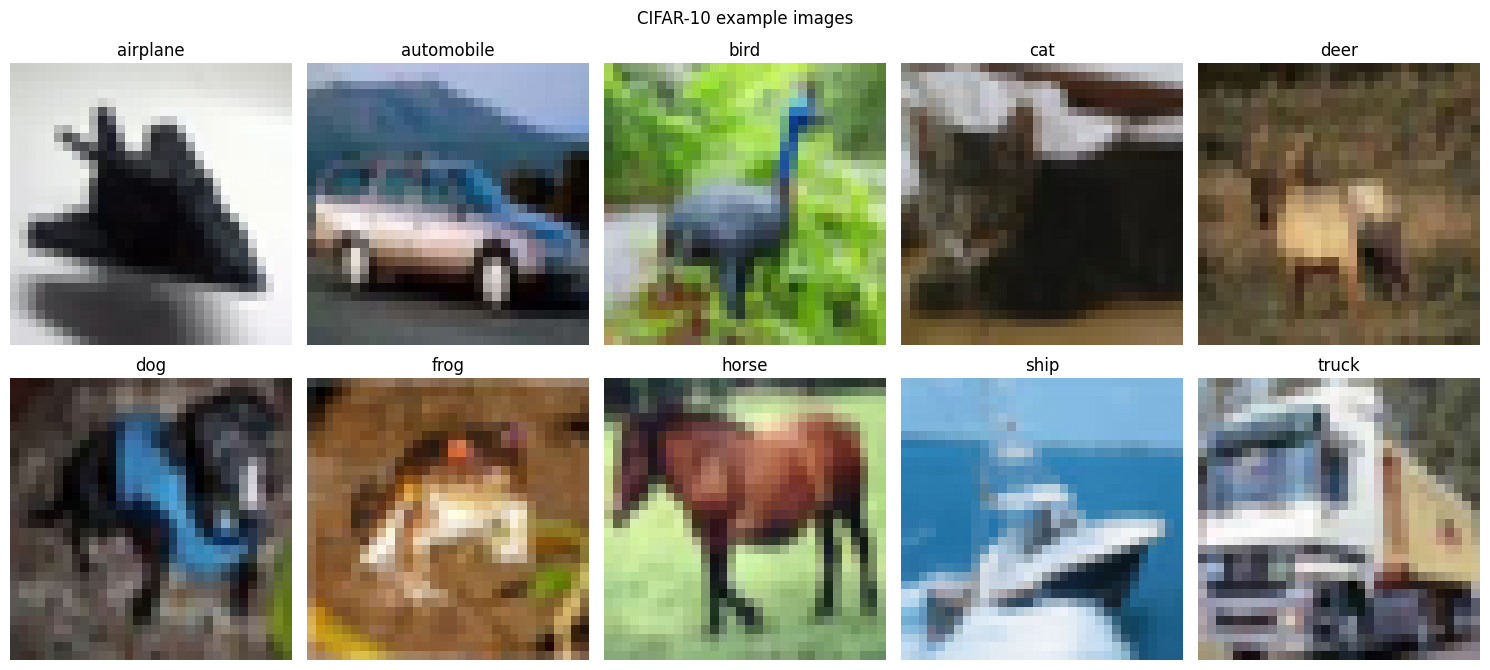

In [7]:
plt.figure(figsize=(15,7))

for i in range(10):
    idx = np.where(y_train_labels == i)[0][0]
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[idx])
    plt.title(class_names[i])
    plt.axis('off')

plt.suptitle('CIFAR-10 example images')
plt.tight_layout()
plt.show()

### Modelling

In [8]:
#Normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

The CNN model produces 10 probabilities at the output, so we convert the labels into one-hot vectors.

In [9]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [10]:
# Building the CNN model
model = Sequential([
    Input(shape=(32, 32, 3)),  # Input layer for 32x32 RGB images

    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', padding='same'),  # Convolutional layer with 32 filters
    BatchNormalization(),  # Normalize the activations
    Conv2D(32, (3, 3), activation='relu', padding='same'),  # Another convolutional layer
    BatchNormalization(),  # Normalize again
    MaxPooling2D((2, 2)),  # Downsample the feature maps
    Dropout(0.25),  # Dropout for regularization (prevent overfitting)

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu', padding='same'),  # Convolutional layer with 64 filters
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Third convolutional block
    Conv2D(128, (3, 3), activation='relu', padding='same'),  # Convolutional layer with 128 filters
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # Fully connected layers
    Flatten(),  # Flatten the 3D feature maps to 1D feature vectors
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(10, activation='softmax')
])

In [11]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

Data Augmentation

In [12]:
datagen = ImageDataGenerator(
    rotation_range=15,        # Rotate the images up to 15 degrees
    width_shift_range=0.1,    # Shift the images horizontally by up to 10% of the width
    height_shift_range=0.1,   # Shift the images vertically by up to 10% of the height
    horizontal_flip=True,     # Flip the images horizontally
)
datagen.fit(x_train)

In [13]:
# We apply Early Stopping when model validation accuracy starts to worsen
early_stopping = EarlyStopping(
    monitor='val_loss',   # Monitor the validation loss
    patience=7,           # Stop if no improvement after 7 epochs
    restore_best_weights=True  # Restore the best model weights
)

In [14]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    epochs=100,
    validation_data=(x_test, y_test),
    callbacks=early_stopping,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 88ms/step - accuracy: 0.1588 - loss: 2.2759 - val_accuracy: 0.1903 - val_loss: 2.1914
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.3172 - loss: 1.7565 - val_accuracy: 0.4146 - val_loss: 1.6559
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.4373 - loss: 1.5295 - val_accuracy: 0.5359 - val_loss: 1.3071
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.5139 - loss: 1.3658 - val_accuracy: 0.5463 - val_loss: 1.3616
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.5663 - loss: 1.2519 - val_accuracy: 0.6252 - val_loss: 1.0967
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.6135 - loss: 1.1553 - val_accuracy: 0.6505 - val_loss: 1.0482
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.6370 - loss: 1.0990 - val_accuracy: 0.6731 - val_loss: 0.9829
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.6637 - loss: 1.0279 - val_

In [15]:
# Evaluating the model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8364 - loss: 0.5046
Test Loss: 0.5033
Test Accuracy: 0.8405


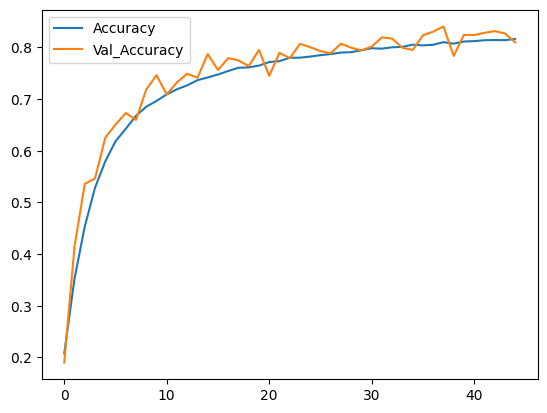

In [16]:
plt.plot(history.history["accuracy"], label="Accuracy")
plt.plot(history.history["val_accuracy"], label="Val_Accuracy")
plt.legend()

The model's training and validation accuracy increased over time and stabilized around 0.8.
The closeness of the training and validation results indicates that there is no overfitting.
Overall, the model has learned well and appears to have strong generalization ability.

In [22]:
# Prediction on test images
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

num_images = 10
indices = np.random.choice(len(x_test), num_images)
images = x_test[indices]
true_labels = np.argmax(y_test[indices], axis=1)
predictions = np.argmax(model.predict(images), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


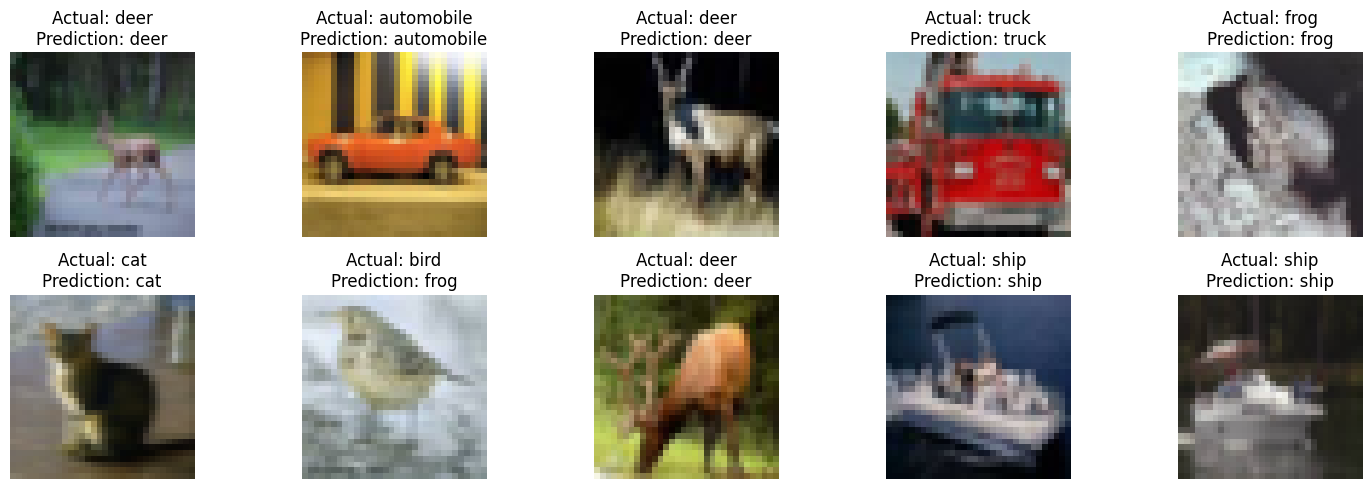

In [23]:
plt.figure(figsize=(15,5))
for i in range(num_images):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    plt.title(f"Actual: {class_names[true_labels[i]]}\nPrediction: {class_names[predictions[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()